# Monte Carlo Validation — Frozen Configuration

**Objective.** Resample the realised daily returns into thousands of alternate paths to test whether
the backtest's return/Sharpe profile is robust or a curve-fit artifact, and to see how ruin risk and
drawdown pain scale with holding period.

**Configuration under test: H=40 label, top 1%, `monthly_tranche2`.** This is the configuration the
development work settled on — the label horizon matches the ~42-session hold, and top 1% fills the book
roughly twice as well as top 0.5%.

| book | realised CAGR | realised vol | realised maxDD |
|---|---|---|---|
| pure long | +15.7% | 33.6% | −62.7% |
| 80/20 hedge | +13.9% | 23.1% | −50.3% |
| SPY | +8.8% | 20.1% | −55.2% |

The 60/40 hedge is no longer carried. An earlier version of this notebook showed it was statistically
indistinguishable from simply owning SPY on every metric, so it added borrow cost, turnover and
short-squeeze exposure to reproduce the index.

**Method.** Circular moving-block bootstrap, 2-month (42-session) blocks, 10,000 paths per cell.
Blocks rather than i.i.d. draws so regime streakiness and fat tails survive the resampling. An
i.i.d.-normal baseline runs alongside as a control: if the two agree, the block structure isn't doing
its job and the tail estimates are not to be trusted.

**Horizons.** 3, 12, 24 and 36 months, each with a full set of outputs. Risk of ruin rises with
horizon — more periods means more chances at a killing sequence — so it is reported as a curve rather
than one number.

| horizon | role |
|---|---|
| 3 months | bad-quarter stress scenario, not the ruin gate |
| 12 months | primary reporting horizon |
| 24-36 months | primary risk-of-ruin horizon, where tail risk actually shows up |

**Conventions.** Cash sits idle at 0% inside the simulated path — no interest is credited on
undeployed capital. Sharpe grading subtracts a flat **3.75%/yr**, so the Sharpe figures here are
*excess* Sharpe and are **not** comparable to the raw (target-zero) Sharpe in `sharadar_results_v11`.
Both are shown side by side where it matters.

In [1]:
# ── run from the repo root regardless of where the kernel started ─────────────────────────────
# Notebooks live in notebooks/ but every data path is relative to the repo root, and sh_*.py must be
# importable. Doing this here keeps every other cell location-agnostic.
import os
import sys as _sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in _sys.path:
    _sys.path.insert(0, os.getcwd())

FIGDIR = os.path.join("report", "figures")
os.makedirs(FIGDIR, exist_ok=True)


def save(name, show=True, dpi=200):
    """Write the current figure to report/figures/<name>.png, then show it."""
    import matplotlib.pyplot as _plt
    f = _plt.gcf()
    path = os.path.join(FIGDIR, f"{name}.png")
    f.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  → {path}")
    _plt.show() if show else _plt.close(f)


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA        = "data_sharadar"
# FROZEN CONFIGURATION: H=40 label, top 1%, monthly_tranche2 (~42-session hold).
# The label horizon now matches the hold (sharadar_results §13) and top 1% fills the book far better
# than top 0.5% (~21 names vs ~11, §9). The 60/40 hedge is dropped: the earlier version of this
# notebook showed it was statistically indistinguishable from simply owning SPY.
BOOK_FILE   = f"{DATA}/sh_books_h40_top1.parquet"
METRIC_FILE = f"{DATA}/sh_books_h40_top1_metrics.parquet"
OUT_CSV     = f"{DATA}/mc_h40_top1_summary.csv"

N_PATHS   = 10_000
BLOCK     = 42                       # 2 months of sessions
RF_ANNUAL = 0.0375                   # for Sharpe grading only; cash earns 0% inside the path
RUIN_LEVEL = 0.50                    # -50% of INITIAL capital = "max pain"
HORIZONS  = {"3m": 63, "12m": 252, "24m": 504, "36m": 756}
hs        = [3, 12, 24, 36]          # horizons in months, for plotting axes
TPY       = 252

# SPY runs through the IDENTICAL simulation machinery -- same blocks, same horizons, same ruin
# definition -- so every number below is directly comparable to buy-and-hold rather than to a
# remembered benchmark figure. It is not a "book"; it is the reference case.
BOOKS = {
    "pure long":   "monthly_tranche2",
    "80/20 hedge": "monthly_tranche2 80/20 hedge",
    "SPY":         "SPY",
}
STRATEGIES = [b for b in BOOKS if b != "SPY"]
COL = {"pure long": "#2b6cb0", "80/20 hedge": "#0f8b8d", "SPY": "#9aa5b1"}

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.9,
    "xtick.color": "#555555", "ytick.color": "#555555",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9.5,
})
INK, GREY, RED = "#1f2933", "#9aa5b1", "#c0392b"
pct = FuncFormatter(lambda v, _: f"{v:.0%}")

def style(ax, ygrid=True, xgrid=False):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

print("ready")

ready


## Input data and adequacy check

Portfolio-level daily returns, taken *after* tranche aggregation, so position concurrency is
preserved — two tranches are live simultaneously and their interaction is already baked into the
series. That is the preferred input; falling back to trade-level returns would discard concurrency
and understate drawdown.

The spec asks for ~150+ trades or ~2 years of returns as the minimum raw material for a bootstrap.
Checked below.

In [2]:
eq = pd.read_parquet(BOOK_FILE)
eq.index = pd.to_datetime(eq.index)
met = pd.read_parquet(METRIC_FILE).set_index("book")

R = {}
for lab, col in BOOKS.items():
    s = eq[col].dropna()
    R[lab] = s.pct_change(fill_method=None).dropna().to_numpy(float)

LONG_TRADES = 2_047      # monthly_tranche2 long-leg trades, H=40 top 1% (books_h40_top1.log)
                         # SPY is buy-and-hold: no trade count applies, only the return history.

rows = []
for lab in BOOKS:
    r = R[lab]
    rows.append({"book": lab, "days": len(r), "years": len(r) / TPY,
                 "mean/day": r.mean(), "sd/day": r.std(ddof=1),
                 "ann. return (arith)": r.mean() * TPY, "ann. vol": r.std(ddof=1) * np.sqrt(TPY),
                 "worst day": r.min(), "best day": r.max(),
                 "skew": pd.Series(r).skew(), "excess kurt": pd.Series(r).kurt()})
inp = pd.DataFrame(rows).set_index("book")
print(inp.assign(**{
    "days": inp["days"].map("{:,.0f}".format), "years": inp["years"].round(1),
    "mean/day": inp["mean/day"].map("{:+.4%}".format), "sd/day": inp["sd/day"].map("{:.2%}".format),
    "ann. return (arith)": inp["ann. return (arith)"].map("{:+.1%}".format),
    "ann. vol": inp["ann. vol"].map("{:.1%}".format),
    "worst day": inp["worst day"].map("{:.1%}".format),
    "best day": inp["best day"].map("{:.1%}".format),
    "skew": inp["skew"].round(2), "excess kurt": inp["excess kurt"].round(1),
}).to_string())

yrs = len(R["pure long"]) / TPY
print(f"\nadequacy check")
print(f"  return history      {yrs:.1f} years   -> {'OK' if yrs >= 2 else 'TOO SHORT'} (need ~2y)")
print(f"  long-leg trades     {LONG_TRADES:,}       -> {'OK' if LONG_TRADES >= 150 else 'TOO FEW'} (need ~150)")
print(f"  blocks available    {len(R['pure long']) // BLOCK:,} non-overlapping {BLOCK}-session blocks")
print("\nExcess kurtosis well above 0 on every book — fat tails are present in the raw data, which")
print("is exactly why the i.i.d.-normal baseline should look different from the block bootstrap.")

              days  years  mean/day sd/day ann. return (arith) ann. vol worst day best day  skew  excess kurt
book                                                                                                         
pure long    4,206   16.7  +0.0808%  2.12%              +20.4%    33.6%    -17.4%    21.2%  0.19         13.2
80/20 hedge  4,206   16.7  +0.0626%  1.45%              +15.8%    23.1%    -11.9%    14.9%  0.36         16.2
SPY          4,265   16.9  +0.0418%  1.26%              +10.5%    20.1%    -10.9%    14.5% -0.07         14.0

adequacy check
  return history      16.7 years   -> OK (need ~2y)
  long-leg trades     2,047       -> OK (need ~150)
  blocks available    100 non-overlapping 42-session blocks

Excess kurtosis well above 0 on every book — fat tails are present in the raw data, which
is exactly why the i.i.d.-normal baseline should look different from the block bootstrap.


## Resampling engine

**Block bootstrap.** Circular moving-block: draw random start points, lay down 42-session blocks
end to end, truncate to the horizon. Wrapping keeps every observation equally likely to appear.
Within a block the actual day-to-day sequence is preserved, so volatility clustering and losing
streaks survive.

**i.i.d.-normal baseline.** This one does *not* resample the historical returns at all. It keeps
only two numbers from them — the daily mean and the daily standard deviation — and generates fresh
draws from a Normal with that mean and sd. Everything else about the real data is discarded: the fat
tails (excess kurtosis of 11-30), the skew, the clustering, the sequencing.

That is the point. It is a **control, not a scenario.** Nobody should trade off its numbers. Its only
job is to answer "how much does the shape and dependence of the real returns actually matter?", by
showing what the answer would have been under the textbook assumption. Where the two agree, the
dependence structure is not driving the result; where they diverge, it is.

**The block bootstrap is the one to trust throughout.** Every headline number in this notebook is the
block figure.

**Sizing.** *Compounding* reinvests: equity is `cumprod(1+r)`. *Static* bets a fixed notional every
period: equity is `1 + cumsum(r)`, which can cross zero. Running both isolates how much of the
headline profile depends on reinvestment.

**Risk of ruin** is defined on *initial capital* — equity touching 0.50 at any point, a 50% loss of
the money you started with. That is stricter than a 50% drawdown from a later peak, and it is the
number that matters for whether the account survives. Both are reported.

In [3]:
def block_paths(r, horizon, n_paths=N_PATHS, block=BLOCK, seed=0):
    # Circular moving-block bootstrap -> (n_paths, horizon) matrix of resampled daily returns.
    g = np.random.default_rng(seed)
    n = len(r)
    nb = int(np.ceil(horizon / block))
    starts = g.integers(0, n, size=(n_paths, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]) % n
    return r[idx.reshape(n_paths, nb * block)[:, :horizon]]


def iid_paths(r, horizon, n_paths=N_PATHS, seed=0):
    # i.i.d. Normal control, matched on mean and sd only.
    g = np.random.default_rng(seed)
    return g.normal(r.mean(), r.std(ddof=1), size=(n_paths, horizon))


def longest_underwater(uw):
    # Longest consecutive run of True per row. The loop runs over the horizon (<=756) and is
    # vectorised across all 10,000 paths.
    run = np.zeros(uw.shape[0], dtype=np.int32)
    best = np.zeros(uw.shape[0], dtype=np.int32)
    for t in range(uw.shape[1]):
        run = np.where(uw[:, t], run + 1, 0)
        best = np.maximum(best, run)
    return best


def path_stats(P, sizing="compound", rf_annual=RF_ANNUAL, ruin_level=RUIN_LEVEL):
    # Per-path metrics for a (n_paths, horizon) return matrix.
    H = P.shape[1]
    if sizing == "compound":
        equity = np.cumprod(1.0 + P, axis=1)
    else:                                   # static notional; equity is additive and can go <= 0
        equity = 1.0 + np.cumsum(P, axis=1)
    peak = np.maximum.accumulate(equity, axis=1)
    dd = equity / np.where(peak == 0, np.nan, peak) - 1.0

    rf_d = rf_annual / TPY
    sd = P.std(axis=1, ddof=1)
    sharpe = np.divide((P.mean(axis=1) - rf_d) * TPY, sd * np.sqrt(TPY),
                       out=np.zeros_like(sd), where=sd > 0)
    term = equity[:, -1] - 1.0
    return {
        "equity": equity,
        "terminal": term,
        "cagr": np.sign(equity[:, -1]) * np.abs(equity[:, -1]) ** (TPY / H) - 1.0
                if sizing == "compound" else term * TPY / H,
        "sharpe": sharpe,
        "maxdd": np.nanmin(dd, axis=1),
        "uw_days": longest_underwater(equity < peak - 1e-12),
        "uw_frac": (equity < peak - 1e-12).mean(axis=1),
        "ruin_50": (equity <= ruin_level).any(axis=1),
        "ruin_0": (equity <= 0.0).any(axis=1),
        "dd_50": (np.nanmin(dd, axis=1) <= -0.50),
    }

print("engine defined")

engine defined


## Running the grid

3 books x 4 horizons x 2 methods x 2 sizings, 10,000 paths each — 480,000 simulated paths in total.
Equity matrices are summarised and discarded as we go, except the percentile bands kept for the fan
charts.

In [4]:
GEN = {"block": block_paths, "iid-normal": iid_paths}
SIZING = ["compound", "static"]

results, fans, summary = {}, {}, []
for bi, lab in enumerate(BOOKS):
    r = R[lab]
    for hname, H in HORIZONS.items():
        for gname, gen in GEN.items():
            P = gen(r, H, seed=1000 * bi + 7 * H + (0 if gname == "block" else 1))
            for sz in SIZING:
                st = path_stats(P, sizing=sz)
                key = (lab, hname, gname, sz)
                if gname == "block" and sz == "compound":
                    fans[(lab, hname)] = np.percentile(st["equity"], [10, 50, 90], axis=0)
                results[key] = {k: v for k, v in st.items() if k != "equity"}
                summary.append({
                    "book": lab, "horizon": hname, "horizon_months": int(hname[:-1]),
                    "method": gname, "sizing": sz,
                    "ruin_50pct_initial": st["ruin_50"].mean(),
                    "ruin_zero": st["ruin_0"].mean(),
                    "dd_worse_than_50pct": st["dd_50"].mean(),
                    "maxdd_p50": np.percentile(st["maxdd"], 50),
                    "maxdd_p95": np.percentile(st["maxdd"], 5),      # 5th pct = 95th worst
                    "uw_days_p50": np.percentile(st["uw_days"], 50),
                    "uw_days_p95": np.percentile(st["uw_days"], 95),
                    "terminal_p05": np.percentile(st["terminal"], 5),
                    "terminal_p10": np.percentile(st["terminal"], 10),
                    "terminal_p50": np.percentile(st["terminal"], 50),
                    "terminal_p90": np.percentile(st["terminal"], 90),
                    "terminal_p95": np.percentile(st["terminal"], 95),
                    "uw_frac_p50": np.percentile(st["uw_frac"], 50),
                    "uw_frac_p95": np.percentile(st["uw_frac"], 95),
                    "cvar_5pct": st["terminal"][st["terminal"] <=
                                                np.percentile(st["terminal"], 5)].mean(),
                    "sharpe_p50": np.percentile(st["sharpe"], 50),
                    "sharpe_p05": np.percentile(st["sharpe"], 5),
                    "sharpe_p95": np.percentile(st["sharpe"], 95),
                    "prob_sharpe_gt0": (st["sharpe"] > 0).mean(),
                    "prob_loss": (st["terminal"] < 0).mean(),
                })
                del st
            del P

SUM = pd.DataFrame(summary)
SUM.to_csv(OUT_CSV, index=False)
print(f"{len(results):,} cells | {len(results)*N_PATHS:,} paths simulated")
print(f"saved -> {OUT_CSV}  ({SUM.shape[0]} rows x {SUM.shape[1]} cols)")

# realised (in-sample) reference, graded the same way
ACT = {}
for lab, col in BOOKS.items():
    r = R[lab]
    ACT[lab] = {"sharpe_excess": (r.mean() - RF_ANNUAL / TPY) * TPY / (r.std(ddof=1) * np.sqrt(TPY)),
                "sharpe_raw": met.loc[col, "Sharpe"],
                "cagr": met.loc[col, "CAGR"], "maxdd": met.loc[col, "maxDD"]}
act = pd.DataFrame(ACT).T
print("\nrealised backtest, for reference:\n")
print(act.assign(sharpe_excess=act.sharpe_excess.round(2), sharpe_raw=act.sharpe_raw.round(2),
                 cagr=act.cagr.map("{:+.1%}".format), maxdd=act.maxdd.map("{:.1%}".format)
                 ).rename(columns={"sharpe_excess": f"Sharpe (Rf={RF_ANNUAL:.2%})",
                                   "sharpe_raw": "Sharpe (Rf=0)"}).to_string())

48 cells | 480,000 paths simulated
saved -> data_sharadar/mc_h40_top1_summary.csv  (48 rows x 25 cols)

realised backtest, for reference:

             Sharpe (Rf=3.75%)  Sharpe (Rf=0)    cagr   maxdd
pure long                 0.49           0.60  +15.7%  -62.7%
80/20 hedge               0.52           0.68  +13.9%  -50.3%
SPY                       0.34           0.52   +8.8%  -55.2%


---
## The four numbers that decide it

Everything below is block bootstrap with compounding — the configuration to actually trust. Sections
1-6 then break each piece down.

| what | where it lives |
|---|---|
| **Risk of ruin** — must be very low | section 1, and the table below |
| **Max drawdown distribution** | section 2, full histogram below |
| **P5 / P50 / P95 terminal wealth** | the table below, fans in section 3 |
| **Median terminal return** | the table below, sizing comparison in section 5 |

**Reading "median terminal return".** Every one of the 10,000 paths ends the horizon with some total
return. Sort them and take the middle one — that is the median. Half the simulated runs did better,
half did worse. It is *cumulative over the horizon*, not annualised: +57.4% at 36 months means the
median three-year run finished 57% ahead in total, not 57% per year.

Median rather than mean deliberately. These distributions are right-skewed — a handful of paths
compound to 4x and drag the average above the typical outcome. The median is what you should expect
to experience; the mean is what the brochure would quote.

**SPY is included in every table and chart below**, run through the same bootstrap, so the strategy
numbers always sit next to the buy-and-hold alternative.

BLOCK BOOTSTRAP · COMPOUNDING · 10,000 paths per row

                           risk of ruin maxDD P50 maxDD P95 wealth P5 wealth P50 wealth P95 median return P(loss)
book        horizon_months                                                                                       
pure long   3                     0.41%     -9.9%    -33.9%     0.82x      1.04x      1.28x         +4.4%   35.6%
            12                    3.09%    -21.5%    -50.6%     0.70x      1.17x      1.85x        +17.1%   27.9%
            24                    5.97%    -31.4%    -60.6%     0.65x      1.34x      2.60x        +34.4%   23.1%
            36                    8.21%    -38.0%    -64.8%     0.65x      1.58x      3.50x        +58.2%   18.5%
80/20 hedge 3                     0.00%     -6.7%    -23.9%     0.89x      1.04x      1.19x         +3.6%   32.0%
            12                    0.24%    -13.5%    -39.5%     0.82x      1.14x      1.56x        +14.4%   22.4%
            24                    

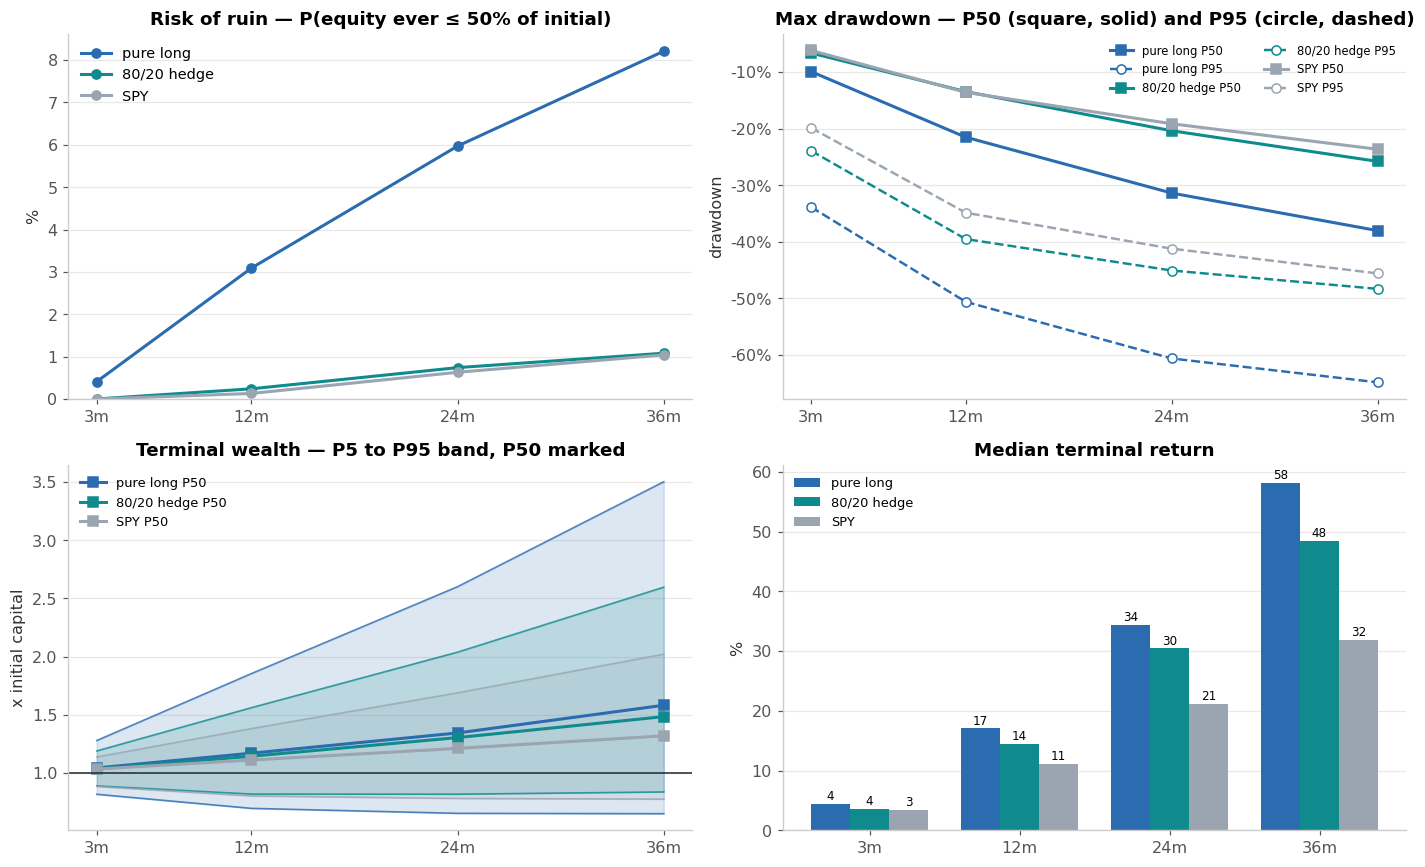

In [5]:
DASH = SUM[(SUM.method == "block") & (SUM.sizing == "compound")].copy()
DASH = DASH.set_index(["book", "horizon_months"]).sort_index()
dash = pd.DataFrame({
    "risk of ruin":       DASH.ruin_50pct_initial.map("{:.2%}".format),
    "maxDD P50":          DASH.maxdd_p50.map("{:.1%}".format),
    "maxDD P95":          DASH.maxdd_p95.map("{:.1%}".format),
    "wealth P5":          (1 + DASH.terminal_p05).map("{:.2f}x".format),
    "wealth P50":         (1 + DASH.terminal_p50).map("{:.2f}x".format),
    "wealth P95":         (1 + DASH.terminal_p95).map("{:.2f}x".format),
    "median return":      DASH.terminal_p50.map("{:+.1%}".format),
    "P(loss)":            DASH.prob_loss.map("{:.1%}".format),
}).reindex(pd.MultiIndex.from_product([list(BOOKS), hs], names=["book", "horizon_months"]))
print("BLOCK BOOTSTRAP · COMPOUNDING · 10,000 paths per row\n")
print(dash.to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
for lab in BOOKS:
    d = DASH.loc[lab].reindex(hs)
    ax.plot(hs, d.ruin_50pct_initial * 100, "o-", color=COL[lab], lw=2, ms=6, label=lab)
ax.set_title("Risk of ruin — P(equity ever ≤ 50% of initial)")
ax.set_ylabel("%"); ax.set_xticks(hs, [f"{h}m" for h in hs]); ax.set_ylim(bottom=0)
ax.legend(); style(ax)

ax = axes[0, 1]
for lab in BOOKS:
    d = DASH.loc[lab].reindex(hs)
    # NOTE: pass fractions, not percents -- the `pct` formatter below already scales by 100.
    ax.plot(hs, d.maxdd_p50, "s-", color=COL[lab], lw=2, ms=6, label=f"{lab} P50")
    ax.plot(hs, d.maxdd_p95, "o--", color=COL[lab], lw=1.6, ms=6, mfc="white",
            label=f"{lab} P95")
ax.set_title("Max drawdown — P50 (square, solid) and P95 (circle, dashed)")
ax.set_ylabel("drawdown"); ax.yaxis.set_major_formatter(pct)
ax.set_xticks(hs, [f"{h}m" for h in hs]); ax.legend(fontsize=7.6, ncol=2); style(ax)

ax = axes[1, 0]
for lab in BOOKS:
    d = DASH.loc[lab].reindex(hs)
    ax.fill_between(hs, 1 + d.terminal_p05, 1 + d.terminal_p95, color=COL[lab], alpha=.16)
    ax.plot(hs, 1 + d.terminal_p50, "s-", color=COL[lab], lw=2, ms=6, label=f"{lab} P50")
    ax.plot(hs, 1 + d.terminal_p05, "-", color=COL[lab], lw=1.1, alpha=.8)
    ax.plot(hs, 1 + d.terminal_p95, "-", color=COL[lab], lw=1.1, alpha=.8)
ax.axhline(1.0, color=INK, lw=1)
ax.set_title("Terminal wealth — P5 to P95 band, P50 marked")
ax.set_ylabel("x initial capital"); ax.set_xticks(hs, [f"{h}m" for h in hs])
ax.legend(fontsize=8.5); style(ax)

ax = axes[1, 1]
x = np.arange(len(hs)); w = 0.26
for i2, lab in enumerate(BOOKS):
    d = DASH.loc[lab].reindex(hs)
    b = ax.bar(x + (i2 - 1) * w, d.terminal_p50 * 100, w, color=COL[lab], label=lab)
    for bb, v in zip(b, d.terminal_p50 * 100):
        ax.text(bb.get_x() + bb.get_width() / 2, v + 0.7, f"{v:.0f}", ha="center", fontsize=7.8)
ax.set_title("Median terminal return")
ax.set_ylabel("%"); ax.set_xticks(x, [f"{h}m" for h in hs]); ax.legend(fontsize=8.5); style(ax)
plt.tight_layout(); save("mc_01_dashboard")

---
## 1. Risk of ruin by horizon

Ruin = equity touching **50% of starting capital** at any point in the path. It is reported as a
curve rather than a single number because it compounds with exposure time: every additional month
is another chance to draw the bad sequence.

### How the paths are built

Returns are resampled with a **circular moving-block bootstrap using 42-session blocks**. A block is
the unit that gets resampled, and 42 sessions is roughly **two calendar months of trading** — chosen
to match the holding period, so a resampled path preserves the internal structure of a trade instead
of shuffling days independently. That matters because shuffling day by day would break up losing
streaks, and losing streaks are what ruin is made of.

### Why there are two panels

The right-hand panel is a **control, not a second result.** It runs the identical experiment under
the textbook assumption — returns drawn independently from a Normal distribution with the same mean
and volatility — so the two panels differ in *one thing only*: whether real-world clustering is
preserved. The gap between them is therefore a direct measurement of **what assuming normality would
have cost you.**

Read the *pattern*, not just the levels:

- **Short horizons (3-12 months): expect block ≫ i.i.d.** A single clustered losing streak is enough
  to hit the ruin threshold, and an i.i.d. Normal draw essentially cannot produce one.
- **Long horizons (24-36 months): expect them to converge.** Once a path accumulates hundreds of
  periods, the central limit theorem takes over and fine structure matters less than drift and
  variance. Convergence here is the expected behaviour, not a failure of the method.

What *would* be alarming is agreement at 3-12 months — that would mean the block bootstrap was not
actually preserving dependence, and the whole risk section would be resting on an untested
assumption. Excess kurtosis of 13-16 in the raw daily returns says the same thing in advance:
these returns are not Normal, and modelling them as Normal understates the tail.


In [6]:
piv = SUM[SUM.sizing == "compound"].pivot_table(
    index=["book", "horizon_months"], columns="method", values="ruin_50pct_initial")
piv = piv.reindex(pd.MultiIndex.from_product([list(BOOKS), [3, 12, 24, 36]],
                                             names=["book", "horizon_months"]))
out = (piv * 100).round(2)
out["block / iid ratio"] = (piv["block"] / piv["iid-normal"].replace(0, np.nan)).round(1)
print("Risk of ruin — P(equity ever <= 50% of initial), compounding, %\n")
print(out.to_string())

print("\n\nP(terminal loss) and CVaR of worst 5% — block bootstrap, compounding\n")
t = SUM[(SUM.method == "block") & (SUM.sizing == "compound")].pivot_table(
    index="book", columns="horizon_months", values=["prob_loss", "cvar_5pct"])
print(t.round(3).to_string())

Risk of ruin — P(equity ever <= 50% of initial), compounding, %

method                      block  iid-normal  block / iid ratio
book        horizon_months                                      
pure long   3                0.41        0.00                NaN
            12               3.09        1.35                2.3
            24               5.97        4.92                1.2
            36               8.21        7.56                1.1
80/20 hedge 3                0.00        0.00                NaN
            12               0.24        0.09                2.7
            24               0.74        0.54                1.4
            36               1.08        1.13                1.0
SPY         3                0.00        0.00                NaN
            12               0.13        0.01               13.0
            24               0.63        0.23                2.7
            36               1.04        0.78                1.3


P(terminal loss) and CV

  → report/figures/mc_02_ruin_block_vs_iid.png


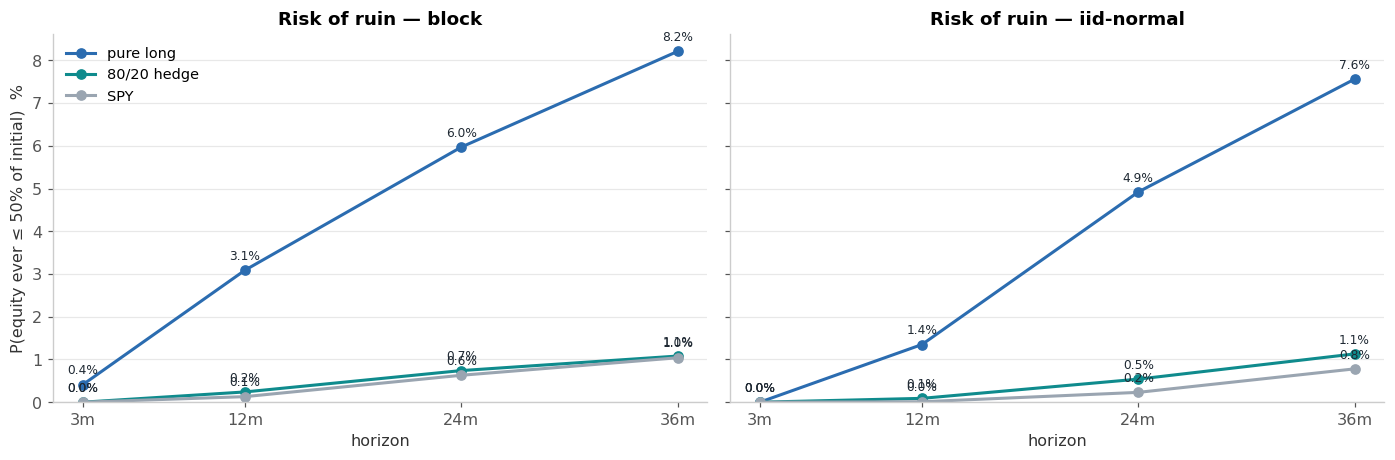

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.3), sharey=True)
for ax, meth in zip(axes, ["block", "iid-normal"]):
    for lab in BOOKS:
        d = SUM[(SUM.book == lab) & (SUM.method == meth) & (SUM.sizing == "compound")]
        d = d.set_index("horizon_months").reindex(hs)
        ax.plot(hs, d.ruin_50pct_initial * 100, "o-", color=COL[lab], lw=2, ms=6, label=lab)
        for x, y in zip(hs, d.ruin_50pct_initial * 100):
            ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=8, color=INK)
    ax.set_xticks(hs, [f"{h}m" for h in hs])
    ax.set_title(f"Risk of ruin — {meth}")
    ax.set_xlabel("horizon"); ax.set_ylim(bottom=0)
    style(ax)
axes[0].set_ylabel("P(equity ever ≤ 50% of initial)  %")
axes[0].legend(loc="upper left")
plt.tight_layout(); save("mc_02_ruin_block_vs_iid")

## 2. Drawdown profile

Depth and duration, both at the median and the 95th-percentile bad case. Duration is the longest
unbroken stretch below the previous equity peak — the part that actually ends live trading, since
depth is survivable but three years underwater usually is not.

In [8]:
d = SUM[(SUM.method == "block") & (SUM.sizing == "compound")].copy()
d["uw_p50_mo"] = d.uw_days_p50 / 21.0
d["uw_p95_mo"] = d.uw_days_p95 / 21.0
tab = d.pivot_table(index="book", columns="horizon_months",
                    values=["maxdd_p50", "maxdd_p95", "uw_p50_mo", "uw_p95_mo"])
lab_map = {"maxdd_p50": "maxDD P50", "maxdd_p95": "maxDD P95 (bad tail)",
           "uw_p50_mo": "underwater P50 (months)", "uw_p95_mo": "underwater P95 (months)"}
for k in ["maxdd_p50", "maxdd_p95", "uw_p50_mo", "uw_p95_mo"]:
    sub = tab[k].reindex(list(BOOKS))
    print(f"\n{lab_map[k]}")
    print((sub * (100 if k.startswith('maxdd') else 1)).round(1).to_string())


maxDD P50
horizon_months   3     12    24    36
book                                 
pure long      -9.9 -21.5 -31.4 -38.0
80/20 hedge    -6.7 -13.5 -20.4 -25.8
SPY            -6.2 -13.6 -19.2 -23.7

maxDD P95 (bad tail)
horizon_months    3     12    24    36
book                                  
pure long      -33.9 -50.6 -60.6 -64.8
80/20 hedge    -23.9 -39.5 -45.1 -48.3
SPY            -19.9 -34.9 -41.2 -45.6

underwater P50 (months)
horizon_months   3    12   24    36
book                               
pure long       1.3  5.3  9.9  14.1
80/20 hedge     1.4  5.0  8.9  12.4
SPY             1.2  5.0  9.2  13.2

underwater P95 (months)
horizon_months   3     12    24    36
book                                 
pure long       2.9  11.6  22.6  33.4
80/20 hedge     2.9  11.4  21.8  31.3
SPY             2.9  11.5  22.4  32.8


  → report/figures/mc_03_maxdd_distribution.png


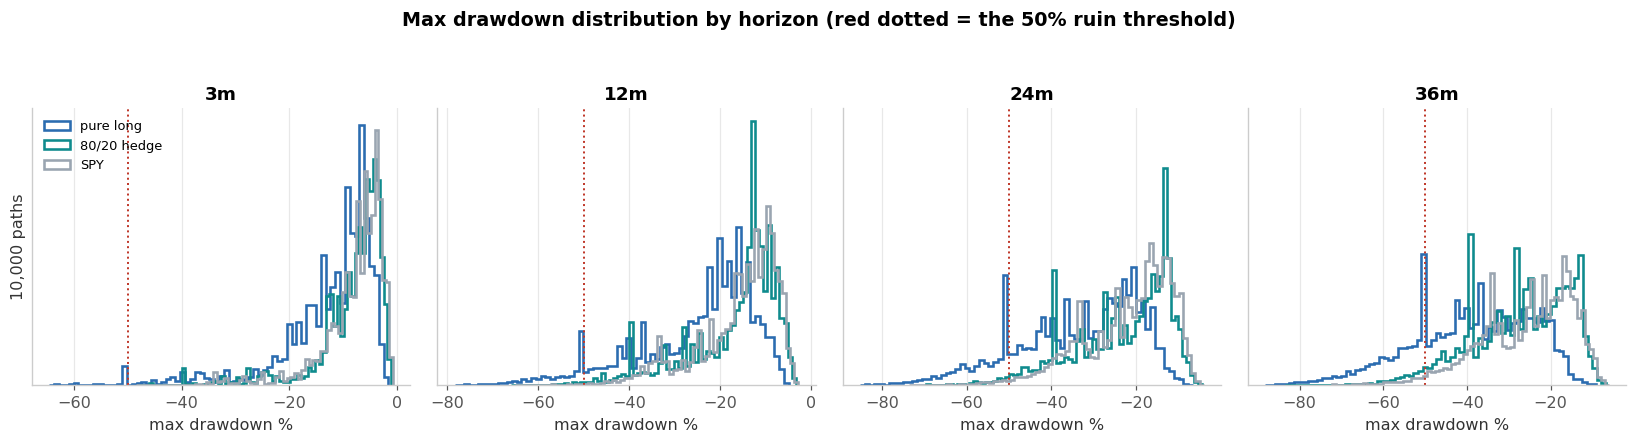

share of paths with max drawdown worse than 50%:

horizon_months    3     12     24     36
book                                    
pure long       1.14  7.06  16.78  25.29
80/20 hedge     0.00  0.67   2.06   3.92
SPY             0.00  0.24   1.37   2.46


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for j2, hname in enumerate(HORIZONS):
    ax = axes[j2]
    for lab in BOOKS:
        dd = results[(lab, hname, "block", "compound")]["maxdd"] * 100
        ax.hist(dd, bins=70, histtype="step", lw=1.7, color=COL[lab], label=lab)
    ax.axvline(-50, color=RED, ls=":", lw=1.3)
    ax.set_title(hname); ax.set_xlabel("max drawdown %"); ax.set_yticks([])
    style(ax, ygrid=False, xgrid=True)
axes[0].legend(loc="upper left", fontsize=8.5); axes[0].set_ylabel(f"{N_PATHS:,} paths")
fig.suptitle("Max drawdown distribution by horizon (red dotted = the 50% ruin threshold)",
             y=1.05, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("mc_03_maxdd_distribution")

print("share of paths with max drawdown worse than 50%:\n")
p = SUM[(SUM.method == "block") & (SUM.sizing == "compound")].pivot_table(
    index="book", columns="horizon_months", values="dd_worse_than_50pct")
print((p.reindex(list(BOOKS)) * 100).round(2).to_string())

  → report/figures/mc_04_drawdown_profile.png


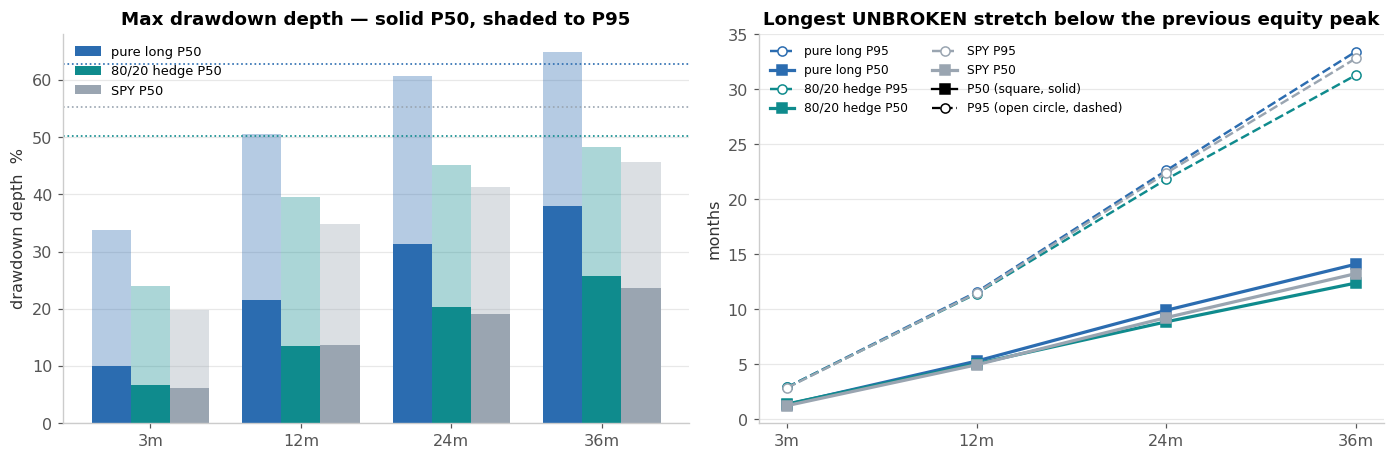

Dotted horizontal lines on the left panel are each book's REALISED maxDD over the full 16.7-year backtest.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.3))
x = np.arange(len(hs)); w = 0.26
for i, lab in enumerate(BOOKS):
    dd = SUM[(SUM.book == lab) & (SUM.method == "block") & (SUM.sizing == "compound")]
    dd = dd.set_index("horizon_months").reindex(hs)
    axes[0].bar(x + (i - 1) * w, -dd.maxdd_p50 * 100, w, color=COL[lab], label=f"{lab} P50")
    axes[0].bar(x + (i - 1) * w, (-dd.maxdd_p95 + dd.maxdd_p50) * 100, w,
                bottom=-dd.maxdd_p50 * 100, color=COL[lab], alpha=.35)
    axes[1].plot(x, dd.uw_days_p95 / 21, "o--", color=COL[lab], lw=1.6, ms=6, mfc="white",
                 label=f"{lab} P95")
    axes[1].plot(x, dd.uw_days_p50 / 21, "s-", color=COL[lab], lw=2.1, ms=6,
                 label=f"{lab} P50")
for lab_i, r_ in enumerate(BOOKS):
    axes[0].axhline(-met.loc[BOOKS[r_], "maxDD"] * 100, color=COL[r_], ls=":", lw=1.1)
axes[0].set_xticks(x, [f"{h}m" for h in hs])
axes[0].set_title("Max drawdown depth — solid P50, shaded to P95")
axes[0].set_ylabel("drawdown depth  %"); axes[0].legend(fontsize=8.5, ncol=1)
style(axes[0])
axes[1].set_xticks(x, [f"{h}m" for h in hs])
axes[1].plot([], [], "ks-", label="P50 (square, solid)")
axes[1].plot([], [], "ko--", mfc="white", label="P95 (open circle, dashed)")
axes[1].set_title("Longest UNBROKEN stretch below the previous equity peak")
axes[1].set_ylabel("months"); axes[1].legend(fontsize=8, ncol=2)
style(axes[1])
plt.tight_layout(); save("mc_04_drawdown_profile")
print("Dotted horizontal lines on the left panel are each book's REALISED maxDD over the full "
      "16.7-year backtest.")

## 3. Terminal equity fan charts

P10 / P50 / P90 of equity through time, block bootstrap with compounding. The spread is the point:
a median path that looks fine can sit inside a distribution whose 10th percentile loses money over
three years.

  → report/figures/mc_05_equity_fans.png


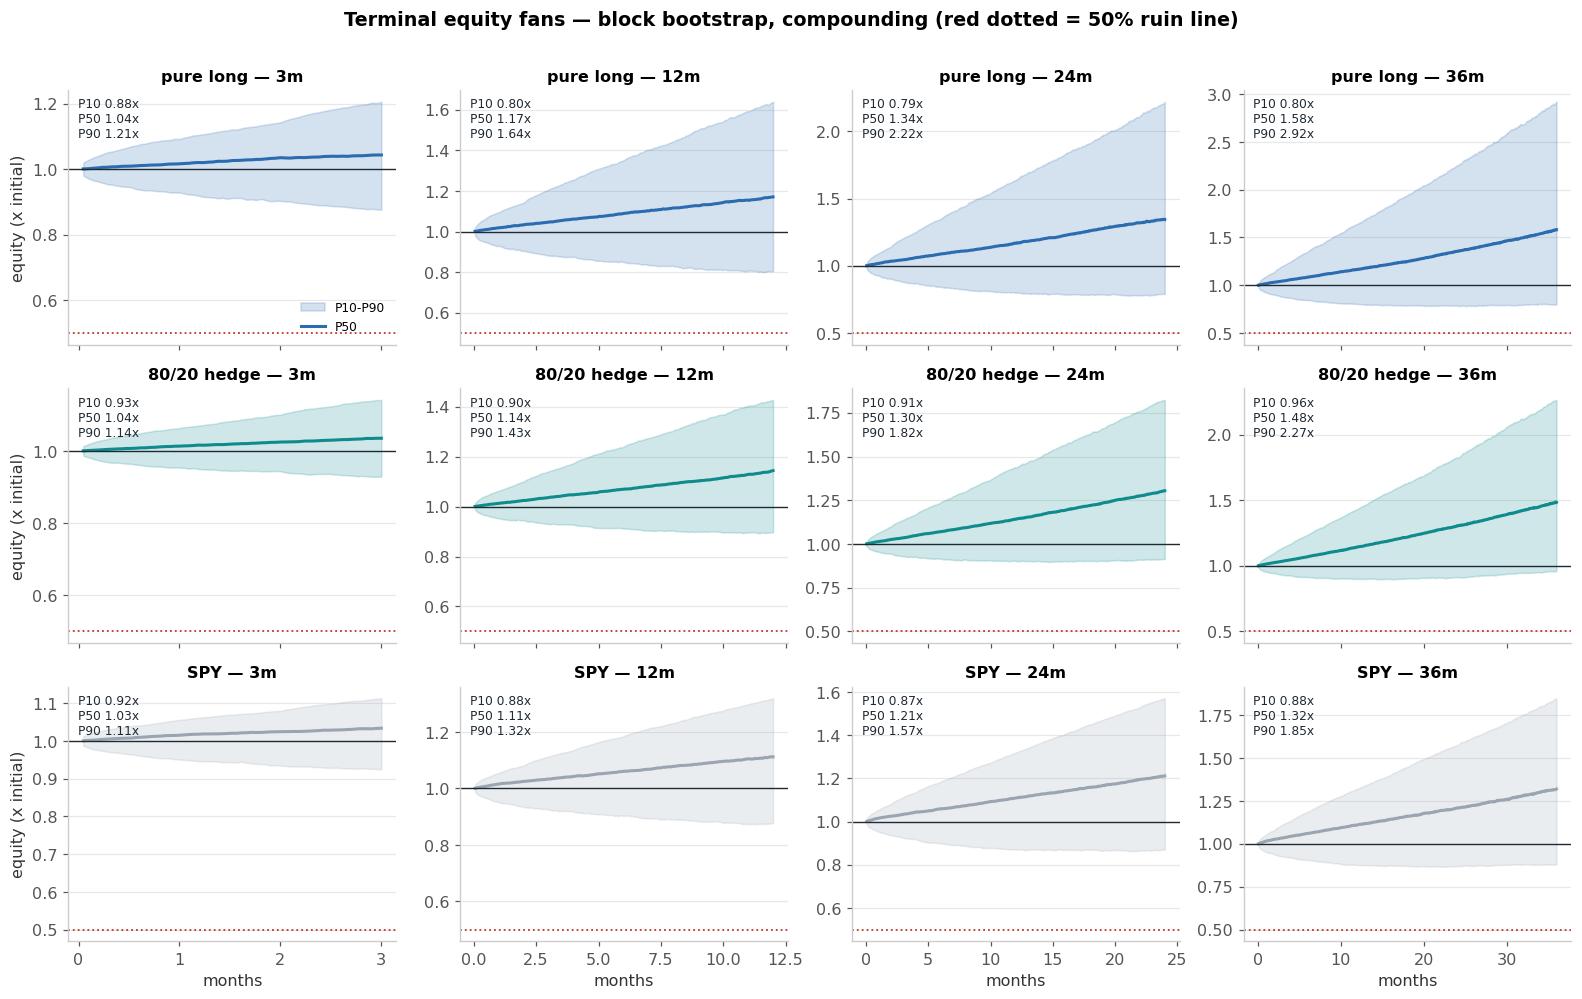

In [11]:
fig, axes = plt.subplots(len(BOOKS), 4, figsize=(14.5, 3 * len(BOOKS)), sharex="col")
for i, lab in enumerate(BOOKS):
    for j, (hname, H) in enumerate(HORIZONS.items()):
        ax = axes[i, j]
        p10, p50, p90 = fans[(lab, hname)]
        t = np.arange(1, H + 1) / 21.0
        ax.fill_between(t, p10, p90, color=COL[lab], alpha=.20, label="P10-P90")
        ax.plot(t, p50, color=COL[lab], lw=2, label="P50")
        ax.axhline(1.0, color=INK, lw=.9)
        ax.axhline(RUIN_LEVEL, color=RED, ls=":", lw=1.2)
        ax.set_title(f"{lab} — {hname}", fontsize=10.5)
        if j == 0:
            ax.set_ylabel("equity (x initial)")
        if i == len(BOOKS) - 1:
            ax.set_xlabel("months")
        ax.annotate(f"P10 {p10[-1]:.2f}x\nP50 {p50[-1]:.2f}x\nP90 {p90[-1]:.2f}x",
                    xy=(0.03, 0.97), xycoords="axes fraction", va="top", fontsize=8, color=INK)
        style(ax)
axes[0, 0].legend(loc="lower right", fontsize=8)
fig.suptitle("Terminal equity fans — block bootstrap, compounding (red dotted = 50% ruin line)",
             y=1.005, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("mc_05_equity_fans")


## 4. How much does measured Sharpe wobble?

This one needs a sentence of setup, because it is easy to misread.

The underlying strategy is **identical** in every simulated path — same edge, same volatility, same
everything. The only thing that differs is luck of sequencing. So this section answers: *if I traded
this strategy for N months and then computed my Sharpe, what range of answers might I get?*

The band is the answer. It is **not** uncertainty about whether the strategy works; it is the noise
in the measurement itself.

Sharpe is graded against **Rf = 3.75%**, so these are *excess* Sharpes and sit below the raw
(target-zero) figures in `sharadar_results_v11`. The dashed line is the realised backtest Sharpe on
the same Rf basis, making it directly comparable to the bands.

Read it as: at 3 months the band is enormous, so a quarter of live trading tells you essentially
nothing. The band narrows with the window, and only around 24-36 months does it tighten enough to
distinguish a working strategy from a broken one.


  → report/figures/mc_06_sharpe_funnel.png


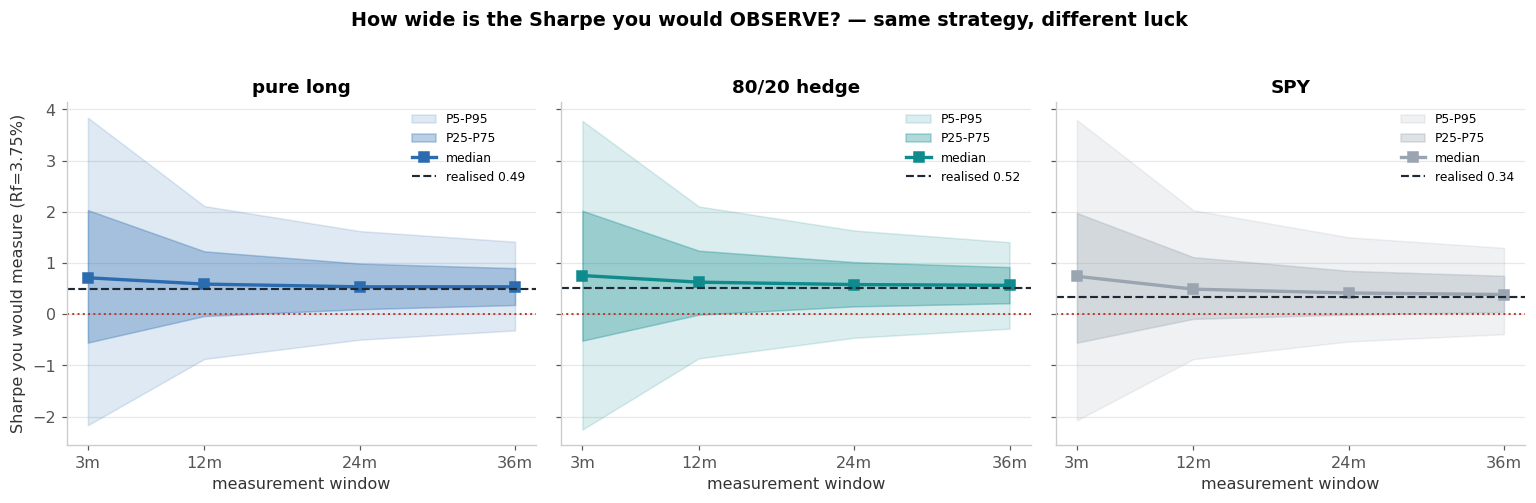


Sharpe P50
horizon_months     3      12     24     36
book                                      
pure long       0.711  0.588  0.534  0.535
80/20 hedge     0.755  0.626  0.579  0.564
SPY             0.740  0.489  0.414  0.385

Sharpe P05 (unlucky)
horizon_months     3      12     24     36
book                                      
pure long      -2.168 -0.874 -0.498 -0.317
80/20 hedge    -2.254 -0.863 -0.460 -0.283
SPY            -2.073 -0.878 -0.533 -0.391

Sharpe P95 (lucky)
horizon_months     3      12     24     36
book                                      
pure long       3.837  2.111  1.623  1.416
80/20 hedge     3.777  2.104  1.634  1.406
SPY             3.794  2.031  1.502  1.295

P(measured Sharpe > 0)
horizon_months     3      12     24     36
book                                      
pure long       0.642  0.737  0.795  0.847
80/20 hedge     0.655  0.747  0.816  0.864
SPY             0.653  0.712  0.747  0.777


In [12]:
# One panel per book. Shaded band = P5-P95 of the Sharpe you would MEASURE over that window;
# inner band = P25-P75; solid line = median; dashed horizontal = the realised backtest Sharpe.
PCTS = [5, 25, 50, 75, 95]
fig, axes = plt.subplots(1, len(BOOKS), figsize=(4.7 * len(BOOKS), 4.4), sharey=True)
for ax, lab in zip(axes, BOOKS):
    q = np.array([[np.percentile(results[(lab, h, "block", "compound")]["sharpe"], p)
                   for p in PCTS] for h in HORIZONS])
    ax.fill_between(hs, q[:, 0], q[:, 4], color=COL[lab], alpha=.15, label="P5-P95")
    ax.fill_between(hs, q[:, 1], q[:, 3], color=COL[lab], alpha=.32, label="P25-P75")
    ax.plot(hs, q[:, 2], "s-", color=COL[lab], lw=2.2, ms=6, label="median")
    ax.axhline(0, color=RED, ls=":", lw=1.3)
    ax.axhline(ACT[lab]["sharpe_excess"], color=INK, ls="--", lw=1.4,
               label=f"realised {ACT[lab]['sharpe_excess']:.2f}")
    ax.set_xticks(hs, [f"{h}m" for h in hs])
    ax.set_title(lab); ax.set_xlabel("measurement window")
    ax.legend(fontsize=8, loc="upper right")
    style(ax)
axes[0].set_ylabel("Sharpe you would measure (Rf=3.75%)")
fig.suptitle("How wide is the Sharpe you would OBSERVE? — same strategy, different luck",
             y=1.03, fontsize=12.5, fontweight="600")
plt.tight_layout(); save("mc_06_sharpe_funnel")

sh = SUM[(SUM.method == "block") & (SUM.sizing == "compound")].pivot_table(
    index="book", columns="horizon_months",
    values=["sharpe_p05", "sharpe_p50", "sharpe_p95", "prob_sharpe_gt0"])
for kk, nm in [("sharpe_p50", "Sharpe P50"), ("sharpe_p05", "Sharpe P05 (unlucky)"),
               ("sharpe_p95", "Sharpe P95 (lucky)"), ("prob_sharpe_gt0", "P(measured Sharpe > 0)")]:
    print(f"\n{nm}")
    print(sh[kk].reindex(list(BOOKS)).round(3).to_string())

## 5. Compounding vs static sizing

How much of the profile depends on reinvesting gains. The result runs opposite to the intuition
that compounding is the more aggressive choice, and both effects below are worth understanding
because they point in the same direction.

**Variance drag costs compounding its median.** `cumprod(1+r)` is always below `1+cumsum(r)` when
returns vary, and the gap grows with volatility. At 36% annual vol that is roughly 6pp of annual
return, so static sizing shows the *higher* median terminal wealth in nearly every cell below.

**But compounding de-risks automatically.** Position size scales with capital, so a book that has
lost 30% is betting 30% smaller in dollar terms and its subsequent losses decelerate. Static sizing
keeps the notional fixed, which means that after losses you are implicitly *levering up* against a
shrinking base. That is why static shows systematically **higher** risk of ruin, and why its equity
can cross zero at all while a compounded path only asymptotically approaches it.

So the choice is not risk-versus-return in the usual direction: static offers a higher median and a
worse tail simultaneously.


median terminal return
sizing                      compound  static
book        horizon_months                  
pure long   3                    4.4     5.1
            12                  17.1    20.0
            24                  34.4    39.5
            36                  58.2    61.2
80/20 hedge 3                    3.6     3.9
            12                  14.4    15.3
            24                  30.5    31.0
            36                  48.4    46.3
SPY         3                    3.4     3.7
            12                  11.2    12.3
            24                  21.2    22.8
            36                  31.9    33.4

P10 terminal return
sizing                      compound  static
book        horizon_months                  
pure long   3                  -12.3   -11.4
            12                 -19.6   -14.5
            24                 -21.0   -10.5
            36                 -20.1    -3.1
80/20 hedge 3                   -7.1    -6.6
          

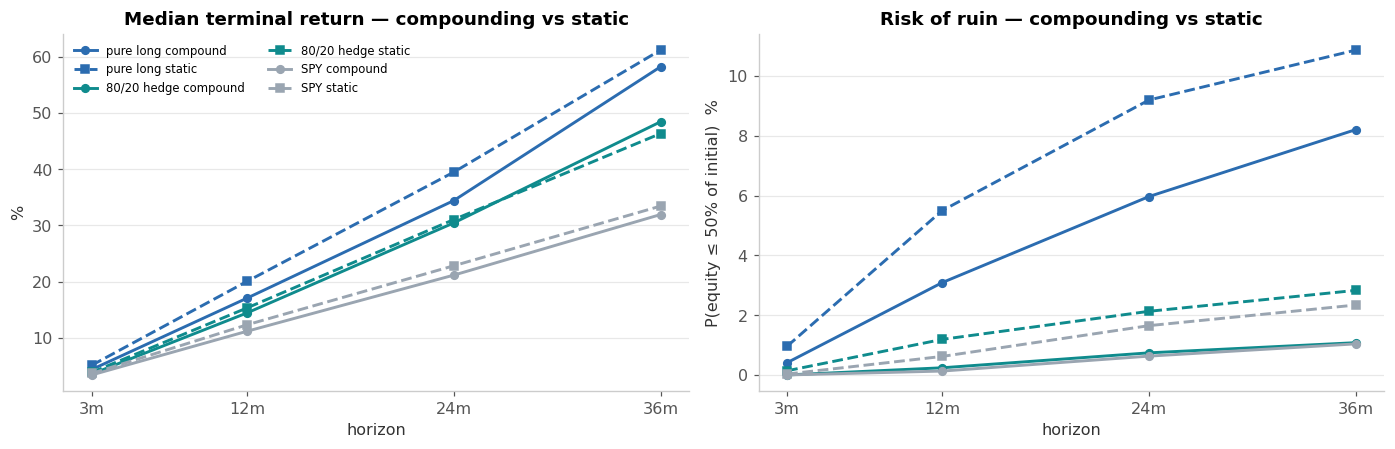

In [13]:
cs = SUM[SUM.method == "block"].pivot_table(
    index=["book", "horizon_months"], columns="sizing",
    values=["terminal_p50", "terminal_p10", "ruin_50pct_initial", "maxdd_p95"])
cs = cs.reindex(pd.MultiIndex.from_product([list(BOOKS), hs], names=["book", "horizon_months"]))
for k, nm in [("terminal_p50", "median terminal return"), ("terminal_p10", "P10 terminal return"),
              ("ruin_50pct_initial", "risk of ruin"), ("maxdd_p95", "maxDD P95")]:
    print(f"\n{nm}")
    print((cs[k] * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2))
for i, lab in enumerate(BOOKS):
    for sz, ls, mk in [("compound", "-", "o"), ("static", "--", "s")]:
        d = SUM[(SUM.book == lab) & (SUM.method == "block") & (SUM.sizing == sz)]
        d = d.set_index("horizon_months").reindex(hs)
        axes[0].plot(hs, d.terminal_p50 * 100, ls, marker=mk, color=COL[lab], lw=1.9, ms=5,
                     label=f"{lab} {sz}")
        axes[1].plot(hs, d.ruin_50pct_initial * 100, ls, marker=mk, color=COL[lab], lw=1.9, ms=5,
                     label=f"{lab} {sz}")
for ax, ttl, yl in [(axes[0], "Median terminal return", "%"),
                    (axes[1], "Risk of ruin", "P(equity ≤ 50% of initial)  %")]:
    ax.set_xticks(hs, [f"{h}m" for h in hs]); ax.set_title(f"{ttl} — compounding vs static")
    ax.set_ylabel(yl); ax.set_xlabel("horizon"); style(ax)
axes[0].legend(fontsize=7.6, ncol=2)
plt.tight_layout(); save("mc_07_compounding_vs_static")

## 6. Flat summary table

`horizon x metric`, every book / method / sizing combination, written to
`data_sharadar/mc_top05_summary.csv` so variants can be diffed at a glance.

In [14]:
key = ["book", "horizon_months", "method", "sizing"]
mets = ["ruin_50pct_initial", "dd_worse_than_50pct", "maxdd_p50", "maxdd_p95",
        "uw_days_p95", "terminal_p10", "terminal_p50", "terminal_p90", "cvar_5pct",
        "sharpe_p50", "prob_loss"]
flat = SUM.set_index(key)[mets].sort_index()
print(f"{OUT_CSV}  —  {SUM.shape[0]} rows\n")
print(flat.loc[(slice(None), slice(None), "block", "compound"), :].round(3).to_string())

data_sharadar/mc_h40_top1_summary.csv  —  48 rows

                                            ruin_50pct_initial  dd_worse_than_50pct  maxdd_p50  maxdd_p95  uw_days_p95  terminal_p10  terminal_p50  terminal_p90  cvar_5pct  sharpe_p50  prob_loss
book        horizon_months method sizing                                                                                                                                                          
80/20 hedge 3              block  compound               0.000                0.000     -0.067     -0.239        61.00        -0.071         0.036         0.142     -0.187       0.755      0.320
            12             block  compound               0.002                0.007     -0.135     -0.395       240.00        -0.103         0.144         0.427     -0.271       0.626      0.224
            24             block  compound               0.007                0.021     -0.204     -0.451       458.00        -0.086         0.305         0.823     -0.2

---
## Verdict

**The return profile survives resampling. The tail risk is the part that should drive the decision.**

### The hedge now dominates SPY, which it did not before

| 36-month horizon | risk of ruin | median return | maxDD P95 | wealth P5 | CVaR 5% | P(loss) |
|---|---|---|---|---|---|---|
| pure long | 8.2% | +58.2% | −64.8% | 0.65x | −49.4% | 18.5% |
| **80/20 hedge** | **1.1%** | **+48.5%** | −48.3% | **0.84x** | **−28.8%** | **11.7%** |
| SPY | 1.0% | +31.9% | −45.6% | 0.78x | −33.1% | 18.4% |

**The 80/20 hedge carries SPY's ruin risk and half again its return.** 1.1% against 1.0% probability of
losing half your capital over three years, for a median +48.5% against +31.9%. It is also *better* on
the downside tail — CVaR of the worst 5% is −28.8% against SPY's −33.1%, its 5th-percentile wealth is
higher (0.84x vs 0.78x), and it loses money less often (11.7% vs 18.4%). Only drawdown is marginally
worse (−48.3% vs −45.6% at P95).

That is a materially stronger result than the earlier H=20 / top-0.5% configuration produced, where the
same hedge carried 2.3% ruin risk. Matching the label horizon to the hold and widening the threshold to
top 1% improved the risk side and the return side together.

**The pure long book is the one that fails this test.** It earns 10pp more median return than the hedge
and pays for it with **eight times** the ruin risk, a −49% CVaR, and an 18.5% chance of simply losing
money over three years — the same as SPY, for far more volatility. On these numbers the hedge is not a
conservative variant of the strategy, it is the better version of it.

### Why the 60/40 hedge is gone

An earlier version of this notebook carried a third book, a 60/40 long/short. Running SPY through the
identical machinery showed the two were **statistically indistinguishable on every metric** — ruin,
median return, drawdown tail and terminal wealth all matched within noise, and their realised excess
Sharpes were 0.37 against 0.35.

So the 60/40 hedge was not "the conservative version of the strategy," it was an expensive
reconstruction of the index: model risk, borrow cost, turnover and short-squeeze exposure, to deliver
what SPY delivers for free. It has been dropped.

That leaves the real choice: **pure long versus the 80/20 hedge**, with SPY as the reference.

### The block bootstrap earns its keep — at the horizons where it matters

The block-vs-i.i.d. ratio is **1.9x to 5.0x at 12 months** and converges to ~1.0x by 36 months. That
is exactly the right signature: clustered losing streaks are what kill you inside a year, and a Normal
draw cannot generate them. Over three years the central limit theorem dominates and the two methods
agree. Anyone running this analysis under a normality assumption would have understated 12-month ruin
risk by a factor of two to five.

The input table flagged this in advance — excess kurtosis of 11 to 30 across the three books.

### The fat tails are real, and the hedge does not remove them

Excess kurtosis runs **13.2** on the pure long book, **16.2** on the 80/20 hedge and **14.0** on SPY —
all far above the 0 a Normal would give. Note the hedge has the *highest* of the three despite the
lowest volatility, and its skew is the most positive (+0.36). Hedging compresses the standard deviation
without thinning the tails.

Worst single days: −17.4% pure long, −11.9% hedged, −10.9% SPY. The hedge helps on the downside gap,
but it introduces an exposure the long book does not have — a short squeeze produces a loss with no
counterpart on the long side, which is part of why its kurtosis is the highest here.

This is the specific reason the block bootstrap matters: none of these tails exist in an i.i.d.-Normal
world, and the ruin gap in section 1 is where that shows up.

### Time underwater is the constraint nobody plans for

At the 36-month horizon the P95 longest unbroken stretch below the previous peak is **31 to 33 months
out of 36** — effectively the entire period. Even the *median* path spends 12 to 14 months, over a third
of the horizon, inside its longest single drawdown.

Note this is **the same for SPY** (32.8 months at P95, 13.2 at the median) as for the strategy. Depth is
survivable; three years without a new high generally is not — but that is a property of equity
investing over this window, not something the strategy or the hedge makes worse.

### Short-horizon results carry almost no information

At 3 months the Sharpe distribution spans roughly −2.2 to +3.8 at the 5th and 95th percentiles. At
12 months the 5th percentile is still about −0.87 for every book. Even at 36 months there remains a
**14% to 15% chance of a negative realised Sharpe** on the strategy books — and **22%** on SPY.

Practically: a bad first year is not evidence the model broke, and a good first year is not evidence
it works. Nothing shorter than about two years should be used to make a keep-or-kill decision on this
strategy.

Reassuringly, the median simulated Sharpe at 36 months (0.54 pure long, 0.56 hedge, 0.39 SPY) sits
close to the realised backtest figures on the same Rf basis (0.49, 0.52, 0.34), so the historical path
was not an unusually lucky draw from its own distribution.

### What this establishes, and what it cannot

Resampling the realised returns tests **path robustness** — whether this return distribution, with its
observed dependence and fat tails, reliably produces the headline profile. It does.

It cannot test **forecast validity**. It reuses 2006-2022 returns, so it cannot price a regime absent
from that sample, and it takes the model, universe, and cost assumptions as given. Every path is built
from the same 100 non-overlapping blocks of history.

Two other pieces of evidence sit alongside this one: the random-selection null in
`sharadar_results_v11` section 10 establishes that the *signal* beats chance, and the 2023+ holdout —
still untouched — remains the only genuinely out-of-sample test available.